In [2]:
import numpy as np

def double_pendulum_rhs(t, y):
    """
    Right-hand side of the ODE system for a double pendulum.
    
    Parameters:
    t: time (not used, but required for ODE solvers)
    y: state vector [theta1, omega1, theta2, omega2]
       theta1, theta2: angles of first and second pendulum
       omega1, omega2: angular velocities
    
    Returns:
    dydt: derivatives [dtheta1/dt, domega1/dt, dtheta2/dt, domega2/dt]
    """
    theta1, omega1, theta2, omega2 = y
    
    # Physical parameters
    m1 = m2 = 1.0  # masses
    l1 = l2 = 1.0  # lengths
    g = 9.81       # gravity
    
    # Derivatives of angles
    dtheta1_dt = omega1
    dtheta2_dt = omega2
    
    # Derivatives of angular velocities
    sin_delta = np.sin(theta1 - theta2)
    cos_delta = np.cos(theta1 - theta2)
    
    denominator1 = l1 * (2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))
    domega1_dt = (
        -g*(2*m1 + m2)*np.sin(theta1) 
        - m2*g*np.sin(theta1 - 2*theta2)
        - 2*sin_delta*m2*(omega2**2*l2 + omega1**2*l1*cos_delta)
    ) / denominator1
    
    denominator2 = l2 * (2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))
    domega2_dt = (
        2*sin_delta*(omega1**2*l1*(m1 + m2) 
        + g*(m1 + m2)*np.cos(theta1) 
        + omega2**2*l2*m2*cos_delta)
    ) / denominator2
    
    return np.array([dtheta1_dt, domega1_dt, dtheta2_dt, domega2_dt])

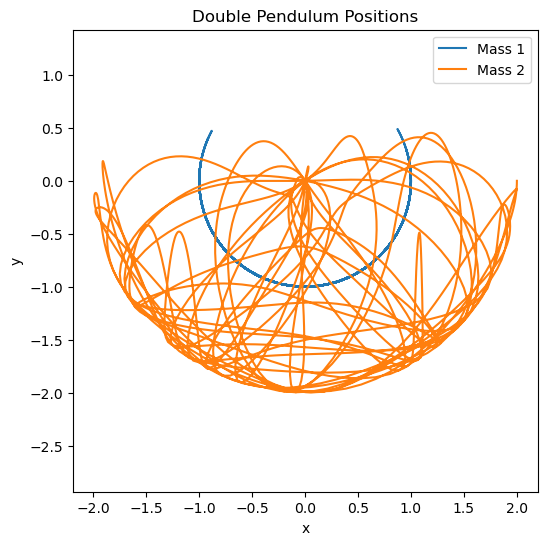

In [7]:
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

t_span = (0, 40)
t_eval = np.linspace(*t_span, 2000)
y0 = np.array([np.pi / 2, 0.0, np.pi / 2, 0.0])

sol = solve_ivp(double_pendulum_rhs, t_span, y0, t_eval=t_eval, rtol=1e-9, atol=1e-9)

theta1, theta2 = sol.y[0], sol.y[2]
l1 = l2 = 1.0
x1 = l1 * np.sin(theta1)
y1 = -l1 * np.cos(theta1)
x2 = x1 + l2 * np.sin(theta2)
y2 = y1 - l2 * np.cos(theta2)

plt.figure(figsize=(6, 6))
plt.plot(x1, y1, label="Mass 1")
plt.plot(x2, y2, label="Mass 2")
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Double Pendulum Positions")
plt.show()

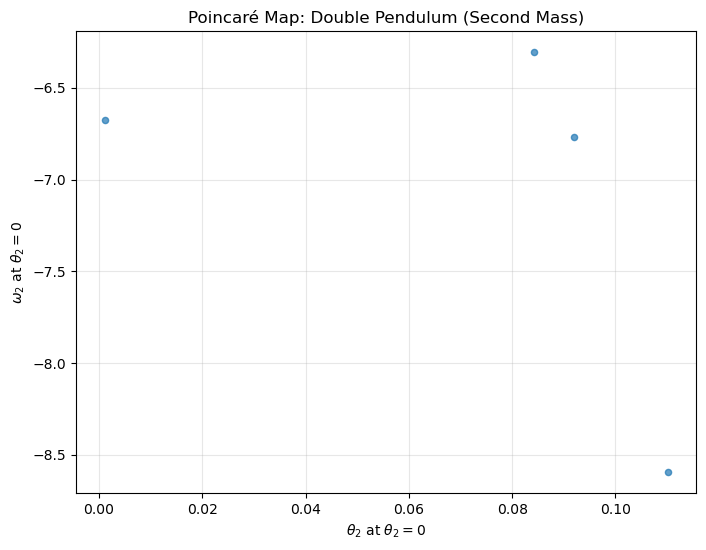

In [10]:
# Create a Poincare map by finding crossings of theta2 = 0
crossings = []
crossings_omega2 = []

for i in range(len(theta2) - 1):
    # Check if theta2 crosses zero (going downward)
    if theta2[i] > 0 and theta2[i + 1] <= 0:
        crossings.append(theta2[i])
        crossings_omega2.append(sol.y[3, i])

crossings = np.array(crossings)
crossings_omega2 = np.array(crossings_omega2)

# Plot the Poincare map
plt.figure(figsize=(8, 6))
plt.scatter(crossings, crossings_omega2, s=20, alpha=0.7)
plt.xlabel(r'$\theta_2$ at $\theta_2 = 0$')
plt.ylabel(r'$\omega_2$ at $\theta_2 = 0$')
plt.title('Poincaré Map: Double Pendulum (Second Mass)')
plt.grid(True, alpha=0.3)
plt.show()

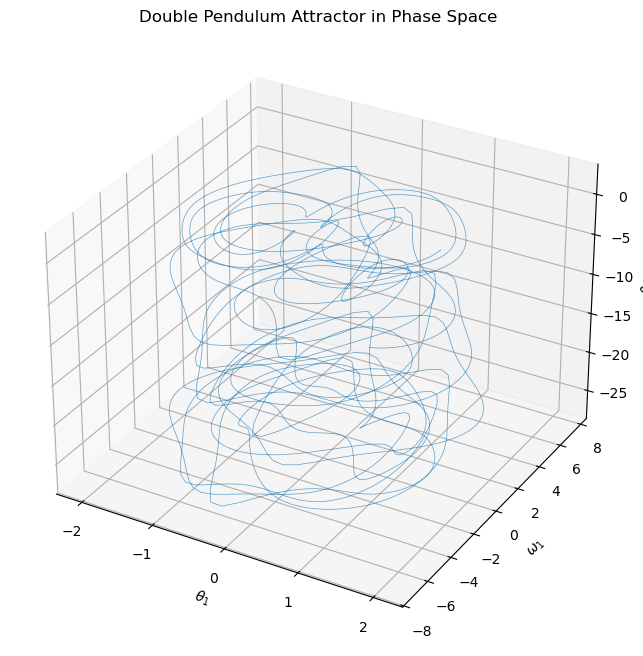

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D plot to visualize the attractor in phase space

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory in 3D phase space (theta1, omega1, theta2)
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5, alpha=0.7)

ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\omega_1$')
ax.set_zlabel(r'$\theta_2$')
ax.set_title('Double Pendulum Attractor in Phase Space')
plt.show()

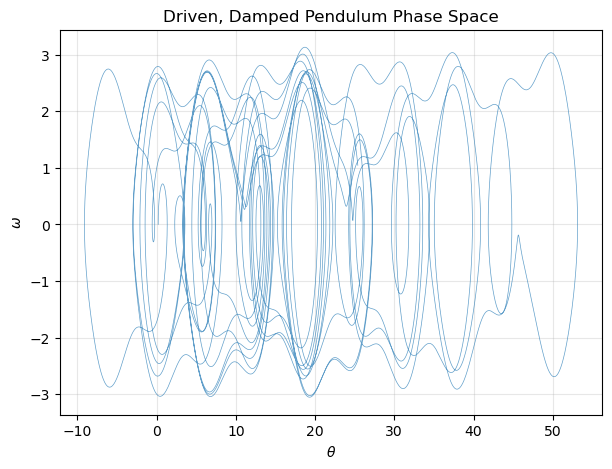

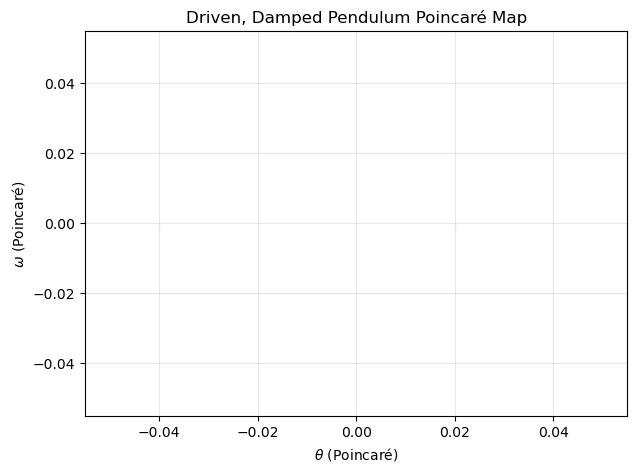

In [ ]:
# Driven, damped pendulum: theta'' + beta*theta' + sin(theta) = gamma*cos(omega_d*t)

def driven_damped_pendulum_rhs(t, y, beta=0.2, gamma=1.2, omega_d=2/3):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -beta * omega - np.sin(theta) + gamma * np.cos(omega_d * t)
    return np.array([dtheta_dt, domega_dt])

t_span_dd = (0, 400)
t_eval_dd = np.linspace(*t_span_dd, 20000)
y0_dd = np.array([0.2, 0.0])

sol_dd = solve_ivp(
    driven_damped_pendulum_rhs,
    t_span_dd,
    y0_dd,
    t_eval=t_eval_dd,
    rtol=1e-9,
    atol=1e-9
)

theta_dd = sol_dd.y[0]
omega_dd = sol_dd.y[1]

# Phase space plot
plt.figure(figsize=(7, 5))
plt.plot(theta_dd, omega_dd, lw=0.5, alpha=0.7)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\omega$')
plt.title('Driven, Damped Pendulum Phase Space')
plt.grid(True, alpha=0.3)
plt.show()

# Poincaré section sampled at drive period
beta, gamma, omega_d = 0.2, 1.2, 2/3
T_d = 2 * np.pi / omega_d
sample_times = np.arange(t_span_dd[0] + 100 * T_d, t_span_dd[1], T_d)
theta_p = np.interp(sample_times, sol_dd.t, theta_dd)
omega_p = np.interp(sample_times, sol_dd.t, omega_dd)

plt.figure(figsize=(7, 5))
plt.scatter(theta_p, omega_p, s=15, alpha=0.7)
plt.xlabel(r'$\theta$ (Poincaré)')
plt.ylabel(r'$\omega$ (Poincaré)')
plt.title('Driven, Damped Pendulum Poincaré Map')
plt.grid(True, alpha=0.3)
plt.show()

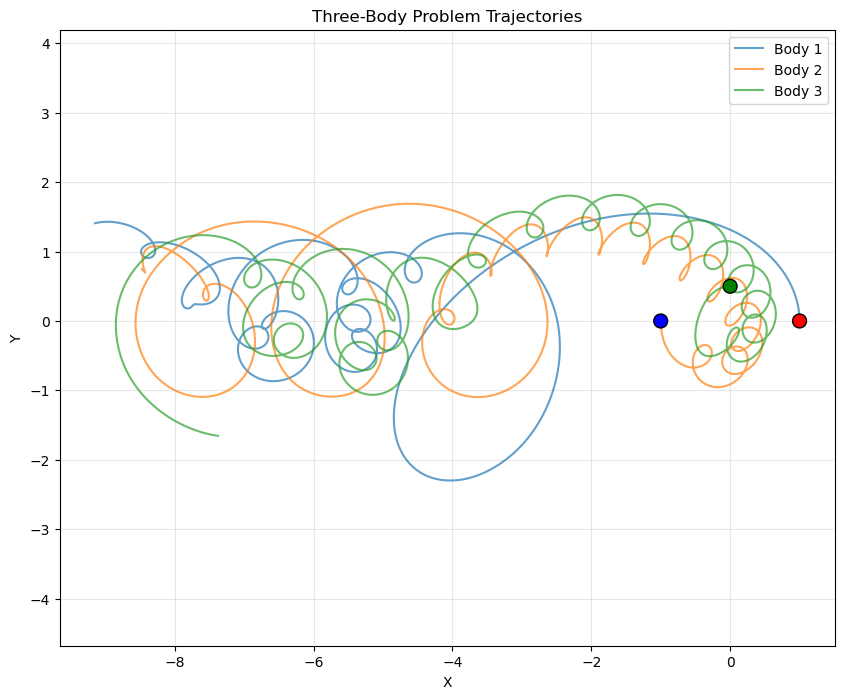

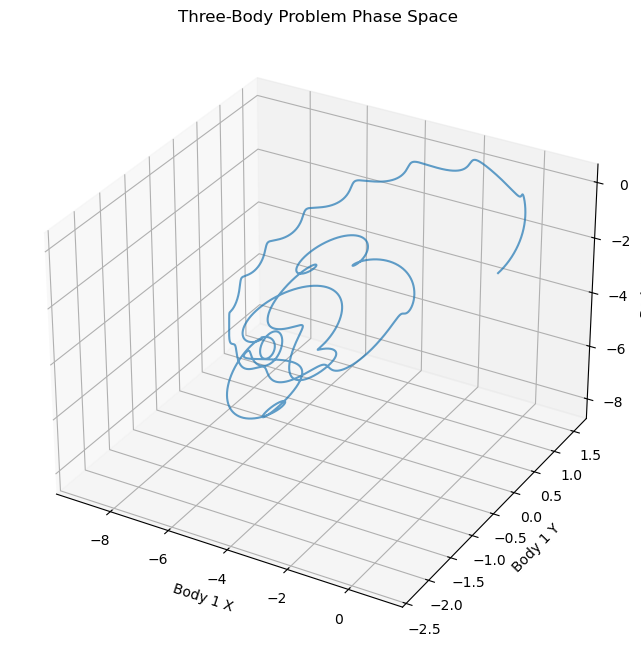

In [14]:
def three_body_rhs(t, y):
    """
    Right-hand side of the ODE system for the three-body problem.
    
    Parameters:
    y: state vector [x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3]
    
    Returns:
    dydt: derivatives of all state variables
    """
    # Extract positions and velocities
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y
    
    # Gravitational constant (normalized units)
    G = 1.0
    
    # Distances
    r12 = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    r13 = np.sqrt((x3 - x1)**2 + (y3 - y1)**2)
    r23 = np.sqrt((x3 - x2)**2 + (y3 - y2)**2)
    
    # Accelerations due to gravity
    ax1 = -G * (x1 - x2) / r12**3 - G * (x1 - x3) / r13**3
    ay1 = -G * (y1 - y2) / r12**3 - G * (y1 - y3) / r13**3
    
    ax2 = -G * (x2 - x1) / r12**3 - G * (x2 - x3) / r23**3
    ay2 = -G * (y2 - y1) / r12**3 - G * (y2 - y3) / r23**3
    
    ax3 = -G * (x3 - x1) / r13**3 - G * (x3 - x2) / r23**3
    ay3 = -G * (y3 - y1) / r13**3 - G * (y3 - y2) / r23**3
    
    return np.array([vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2, vx3, vy3, ax3, ay3])

# Initial conditions: three bodies in a chaotic configuration
y0_3b = np.array([
    1.0, 0.0, 0.0, 1.0,       # Body 1: position (1, 0), velocity (0, 1)
    -1.0, 0.0, 0.0, -1.0,     # Body 2: position (-1, 0), velocity (0, -1)
    0.0, 0.5, -0.5, 0.0       # Body 3: position (0, 0.5), velocity (-0.5, 0)
])

# Solve ODE
t_span_3b = (0, 50)
t_eval_3b = np.linspace(*t_span_3b, 5000)

sol_3b = solve_ivp(three_body_rhs, t_span_3b, y0_3b, t_eval=t_eval_3b, rtol=1e-9, atol=1e-9)

# Extract trajectories
x1_3b, y1_3b = sol_3b.y[0], sol_3b.y[1]
x2_3b, y2_3b = sol_3b.y[4], sol_3b.y[5]
x3_3b, y3_3b = sol_3b.y[8], sol_3b.y[9]

# Plot trajectories
plt.figure(figsize=(10, 8))
plt.plot(x1_3b, y1_3b, label='Body 1', alpha=0.7, lw=1.5)
plt.plot(x2_3b, y2_3b, label='Body 2', alpha=0.7, lw=1.5)
plt.plot(x3_3b, y3_3b, label='Body 3', alpha=0.7, lw=1.5)
plt.scatter([x1_3b[0], x2_3b[0], x3_3b[0]], [y1_3b[0], y2_3b[0], y3_3b[0]], 
            s=100, marker='o', c=['red', 'blue', 'green'], edgecolors='black', zorder=5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Three-Body Problem Trajectories')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# 3D phase space visualization (x1, y1, x2)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x1_3b, y1_3b, x2_3b, lw=1.5, alpha=0.7)
ax.set_xlabel('Body 1 X')
ax.set_ylabel('Body 1 Y')
ax.set_zlabel('Body 2 X')
ax.set_title('Three-Body Problem Phase Space')
plt.show()